# TIMER-Graph: Working Examples & Demonstrations

**Purpose**: Detailed visualization of TIMER-Graph algorithm behavior with real clinical examples.

This notebook provides:
1. **Step-by-step scoring walkthrough** with actual queries
2. **Visual explanation of intent classification**
3. **Ranking comparison with score breakdowns**
4. **Clinical case studies from MIMIC-IV data**

---

In [1]:
# === Environment Setup ===
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import json
from pathlib import Path
import re

# Professional publication style
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Custom color palette (colorblind-friendly)
COLORS = {
    'primary': '#2563EB',      # Blue
    'secondary': '#DC2626',    # Red
    'success': '#16A34A',      # Green
    'warning': '#F59E0B',      # Amber
    'neutral': '#6B7280',      # Gray
    'light': '#F3F4F6',        # Light Gray
    'current': '#10B981',      # Emerald
    'historical': '#EF4444',   # Rose
    'trend': '#8B5CF6',        # Violet
}

# Paths
ROOT = Path('..').resolve()
DATA_MOCKS = ROOT / 'data' / 'mocks'
RESULTS_P5 = ROOT / 'results' / 'phase5'
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

print(f'✓ Environment configured')
print(f'  Root: {ROOT}')

✓ Environment configured
  Root: /home/harry/Desktop/research/poc/clinical-rag-research/visualizations


---
## 1. TIMER-Graph Algorithm Walkthrough

The TIMER scoring formula:

$$\text{Score}(d) = \alpha \cdot S_{semantic}(q, d) + \beta_{intent} \cdot e^{-\lambda \cdot t}$$

Where:
- $S_{semantic}$: Semantic similarity from embedding model
- $\beta_{intent}$: Intent-modulated weight (+0.8 for current, -0.3 for historical)
- $\lambda$: Decay rate (0.005)
- $t$: Days since document creation

In [2]:
# === TIMERScorer Implementation (for demonstration) ===
class TIMERScorer:
    """Temporal Intent-Modulated Entity Retrieval Scorer"""
    
    # Hyperparameters
    ALPHA = 1.0
    BETA_CURRENT = 0.8
    BETA_HISTORICAL = -0.3
    BETA_TREND = 0.4
    LAMBDA_DECAY = 0.005
    CONFIDENCE_THRESHOLD = 0.40
    
    # Intent patterns
    HISTORICAL_PATTERNS = [
        r"history of", r"previous", r"past", r"long[- ]term", r"chronic",
        r"diagnosed in", r"recurrence", r"family history", 
        r"first admission", r"initial", r"original", r"ever been", r"earliest"
    ]
    
    CURRENT_PATTERNS = [
        r"current", r"now", r"today", r"latest", r"recent", 
        r"discharge", r"presenting", r"complaint", r"plan"
    ]
    
    @classmethod
    def classify_intent(cls, query: str):
        """Classify query intent using regex patterns."""
        query_lower = query.lower()
        
        h_score = sum(1 for p in cls.HISTORICAL_PATTERNS if re.search(p, query_lower))
        c_score = sum(1 for p in cls.CURRENT_PATTERNS if re.search(p, query_lower))
        
        total = h_score + c_score
        if total == 0:
            return "current", 0.5, {"historical": 0, "current": 0}
        
        scores = {"historical": h_score, "current": c_score}
        best = max(scores, key=scores.get)
        confidence = scores[best] / total
        
        return best, confidence, scores
    
    @classmethod
    def get_beta(cls, intent: str, confidence: float):
        """Get beta value based on intent."""
        if confidence < cls.CONFIDENCE_THRESHOLD:
            return 0.0
        if intent == "historical":
            return cls.BETA_HISTORICAL
        elif intent == "current":
            return cls.BETA_CURRENT
        else:
            return cls.BETA_TREND
    
    @classmethod
    def compute_decay(cls, offset_days: float):
        """Compute temporal decay factor."""
        return np.exp(-cls.LAMBDA_DECAY * offset_days)
    
    @classmethod
    def score(cls, semantic: float, offset_days: float, beta: float):
        """Compute final TIMER score."""
        decay = cls.compute_decay(offset_days)
        return cls.ALPHA * semantic + beta * decay

print('✓ TIMERScorer loaded')

✓ TIMERScorer loaded


---
## 2. Example Query Analysis

Let's walk through **real clinical queries** and visualize how TIMER processes them.

In [3]:
# === Define Example Queries ===
EXAMPLE_QUERIES = [
    {
        "id": "Q1",
        "text": "What was the patient's blood pressure during their first admission?",
        "expected_intent": "historical",
        "clinical_context": "Checking baseline vitals from initial hospitalization"
    },
    {
        "id": "Q2", 
        "text": "What is the patient's current medication list?",
        "expected_intent": "current",
        "clinical_context": "Reviewing active prescriptions for discharge planning"
    },
    {
        "id": "Q3",
        "text": "Has the patient ever been diagnosed with diabetes?",
        "expected_intent": "historical",
        "clinical_context": "Checking complete medical history for comorbidities"
    },
    {
        "id": "Q4",
        "text": "What is the discharge diagnosis?",
        "expected_intent": "current",
        "clinical_context": "Documenting final diagnosis for billing/records"
    },
]

# Analyze each query
query_analysis = []
for q in EXAMPLE_QUERIES:
    intent, conf, scores = TIMERScorer.classify_intent(q['text'])
    beta = TIMERScorer.get_beta(intent, conf)
    query_analysis.append({
        **q,
        'detected_intent': intent,
        'confidence': conf,
        'pattern_counts': scores,
        'beta': beta,
        'correct': intent == q['expected_intent']
    })

df_queries = pd.DataFrame(query_analysis)
print("Query Intent Classification Results:")
print(df_queries[['id', 'detected_intent', 'expected_intent', 'confidence', 'beta', 'correct']].to_string(index=False))

Query Intent Classification Results:
id detected_intent expected_intent  confidence  beta  correct
Q1      historical      historical         1.0  -0.3     True
Q2         current         current         1.0   0.8     True
Q3      historical      historical         1.0  -0.3     True
Q4         current         current         1.0   0.8     True


✓ Saved: plots/ex1_intent_classification.png


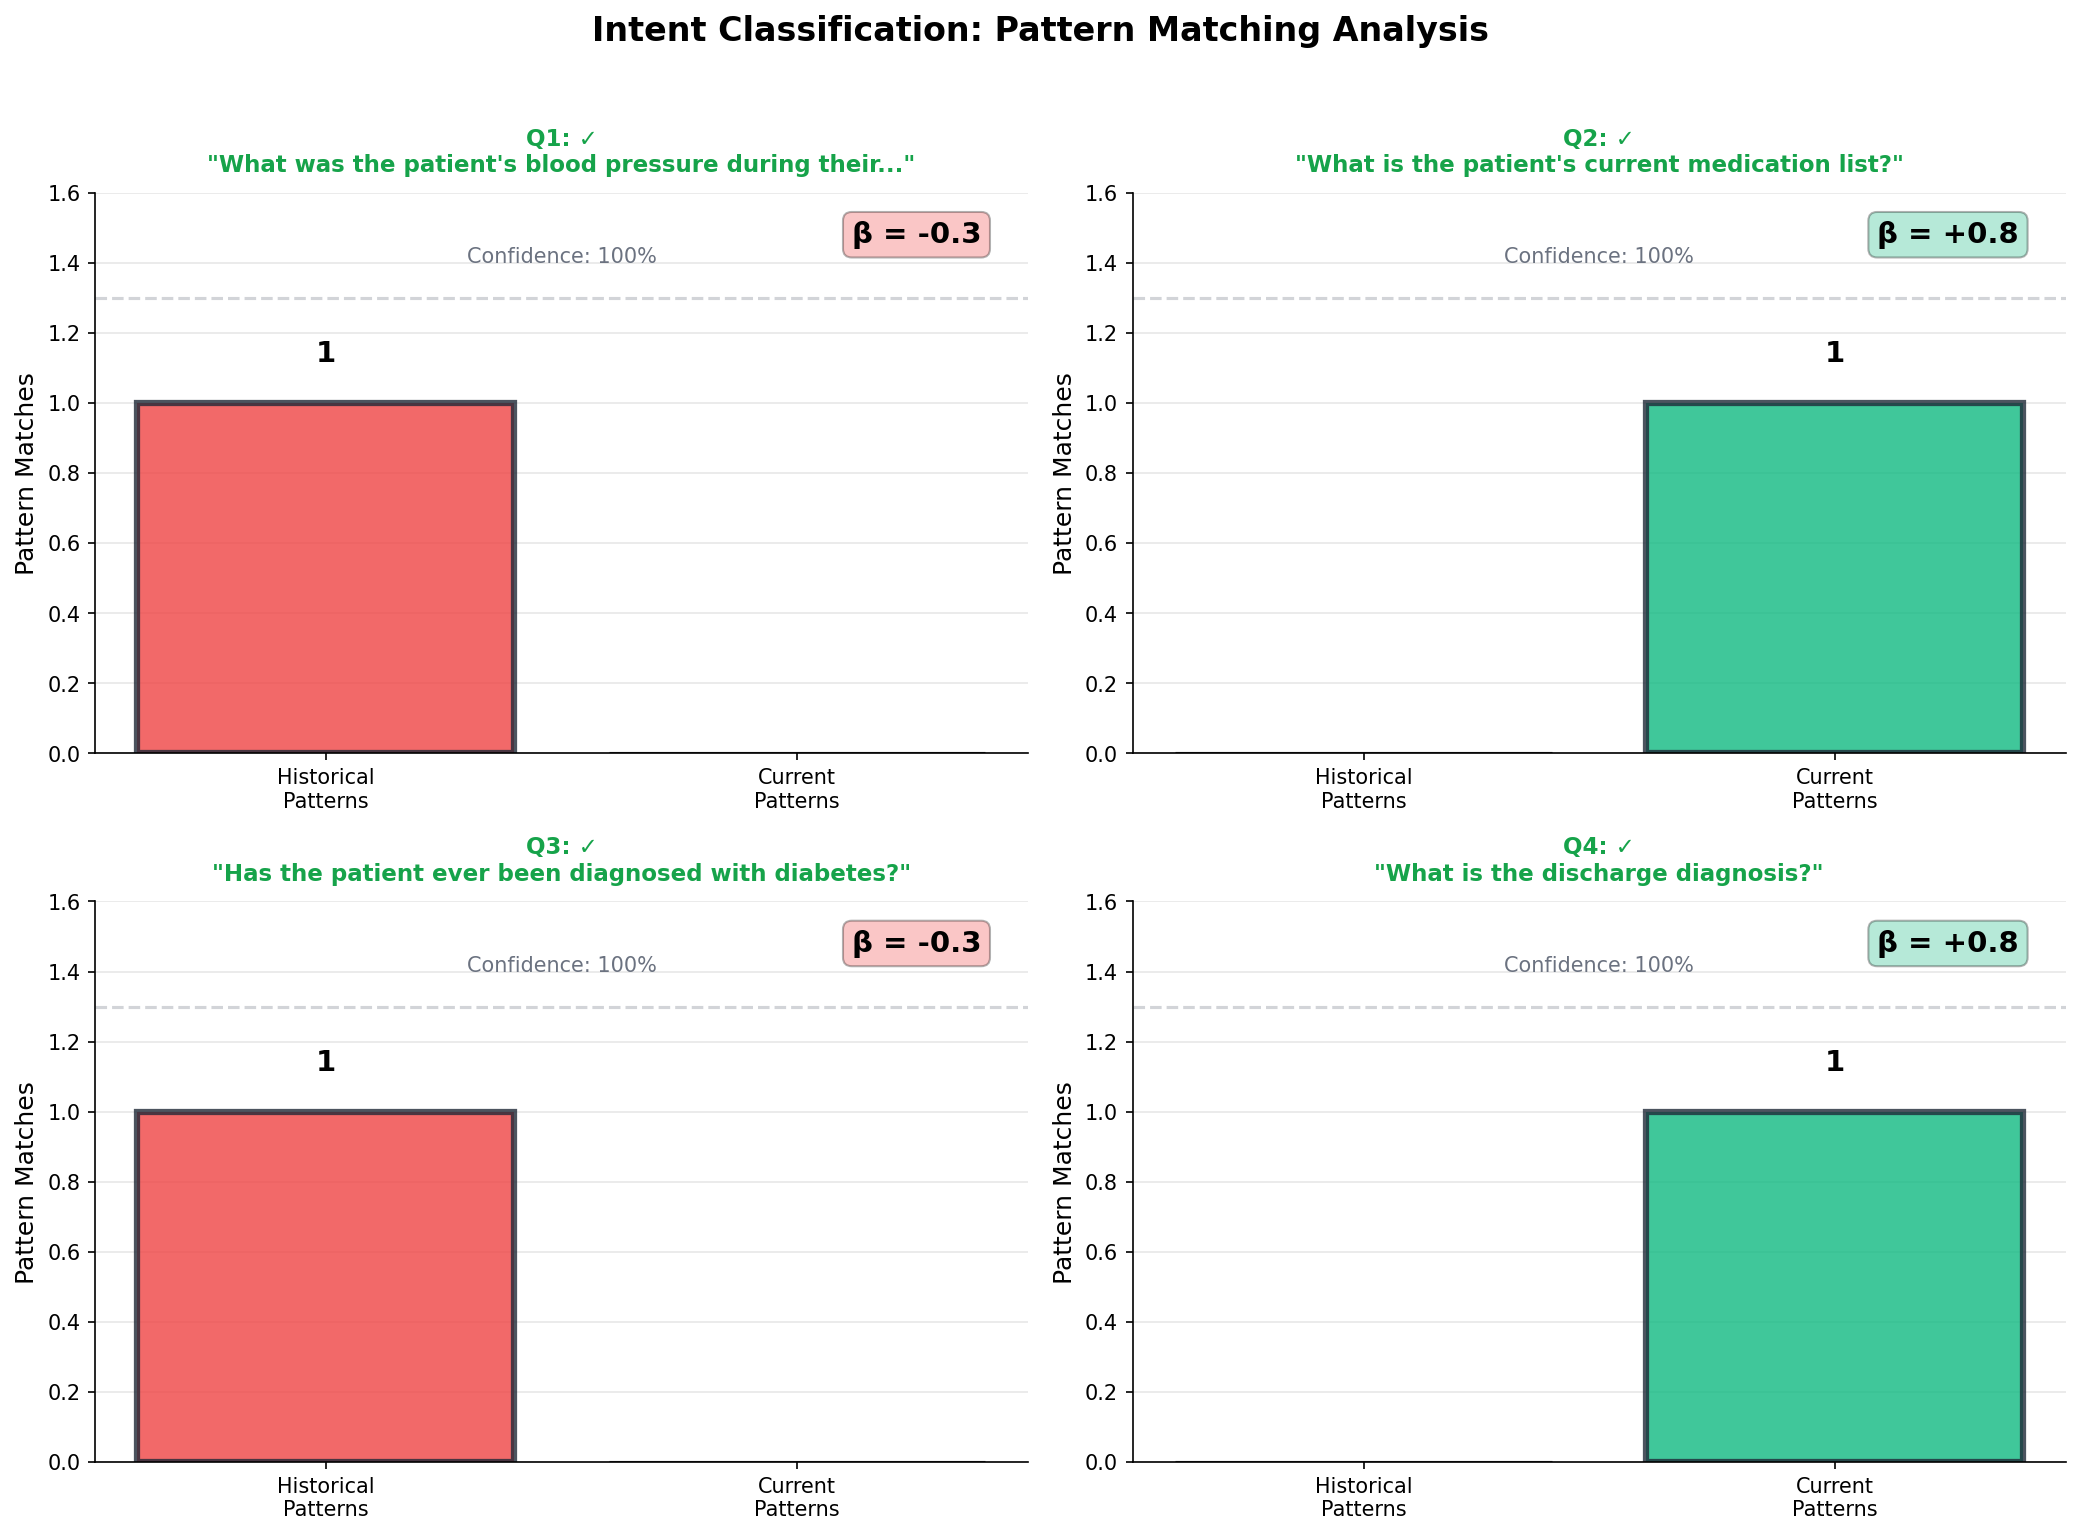

In [4]:
# === Figure 1: Intent Classification Visualization ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (ax, qa) in enumerate(zip(axes.flat, query_analysis)):
    # Extract data
    query_text = qa['text']
    intent = qa['detected_intent']
    conf = qa['confidence']
    beta = qa['beta']
    correct = qa['correct']
    h_count = qa['pattern_counts']['historical']
    c_count = qa['pattern_counts']['current']
    
    # Create bar chart for pattern matches
    categories = ['Historical\nPatterns', 'Current\nPatterns']
    counts = [h_count, c_count]
    colors = [COLORS['historical'], COLORS['current']]
    
    bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Highlight winner
    winner_idx = 0 if intent == 'historical' else 1
    bars[winner_idx].set_edgecolor('#1F2937')
    bars[winner_idx].set_linewidth(3)
    
    # Add count labels
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                   str(count), ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    # Title with query
    title_color = COLORS['success'] if correct else COLORS['secondary']
    status = '✓' if correct else '✗'
    ax.set_title(f"{qa['id']}: {status}\n\"{query_text[:50]}...\"" if len(query_text) > 50 else f"{qa['id']}: {status}\n\"{query_text}\"",
                fontsize=11, color=title_color, pad=10)
    
    # Add beta annotation
    beta_color = COLORS['historical'] if beta < 0 else COLORS['current'] if beta > 0 else COLORS['neutral']
    ax.annotate(f'β = {beta:+.1f}', xy=(0.95, 0.95), xycoords='axes fraction',
               fontsize=14, fontweight='bold', ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=beta_color, alpha=0.3))
    
    # Confidence bar
    ax.axhline(y=max(counts) * 1.3, color=COLORS['neutral'], linestyle='--', alpha=0.3)
    ax.text(0.5, max(counts) * 1.4, f'Confidence: {conf:.0%}', 
           ha='center', fontsize=10, color=COLORS['neutral'])
    
    ax.set_ylabel('Pattern Matches')
    ax.set_ylim(0, max(max(counts), 1) * 1.6)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, alpha=0.3)

plt.suptitle('Intent Classification: Pattern Matching Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ex1_intent_classification.png', bbox_inches='tight', facecolor='white')
plt.savefig(PLOTS_DIR / 'ex1_intent_classification.pdf', bbox_inches='tight')
print(f'✓ Saved: {PLOTS_DIR}/ex1_intent_classification.png')
plt.show()

---
## 3. Score Component Breakdown

Visualizing how semantic and temporal components combine for a specific query.

In [5]:
# === Scenario: Historical Query with Two Candidate Notes ===
scenario = {
    "query": "What was the patient's blood pressure during their first admission?",
    "intent": "historical",
    "beta": -0.3,
    "notes": [
        {"id": "Note A (Recent)", "semantic": 0.85, "offset_days": 7, "content": "BP: 140/90 mmHg (current admission)"},
        {"id": "Note B (Historical)", "semantic": 0.82, "offset_days": 730, "content": "BP: 120/80 mmHg (first admission 2023)"},
    ]
}

# Calculate scores
for note in scenario['notes']:
    decay = TIMERScorer.compute_decay(note['offset_days'])
    note['decay'] = decay
    note['temporal_contrib'] = scenario['beta'] * decay
    note['baseline_score'] = note['semantic']
    note['timer_score'] = TIMERScorer.score(note['semantic'], note['offset_days'], scenario['beta'])

print("Score Breakdown:")
for note in scenario['notes']:
    print(f"  {note['id']}:")
    print(f"    Semantic: {note['semantic']:.3f}")
    print(f"    Decay e^(-λt): {note['decay']:.4f}")
    print(f"    Temporal (β×decay): {note['temporal_contrib']:+.4f}")
    print(f"    TIMER Score: {note['timer_score']:.3f}")
    print()

Score Breakdown:
  Note A (Recent):
    Semantic: 0.850
    Decay e^(-λt): 0.9656
    Temporal (β×decay): -0.2897
    TIMER Score: 0.560

  Note B (Historical):
    Semantic: 0.820
    Decay e^(-λt): 0.0260
    Temporal (β×decay): -0.0078
    TIMER Score: 0.812



✓ Saved: plots/ex2_score_waterfall.png


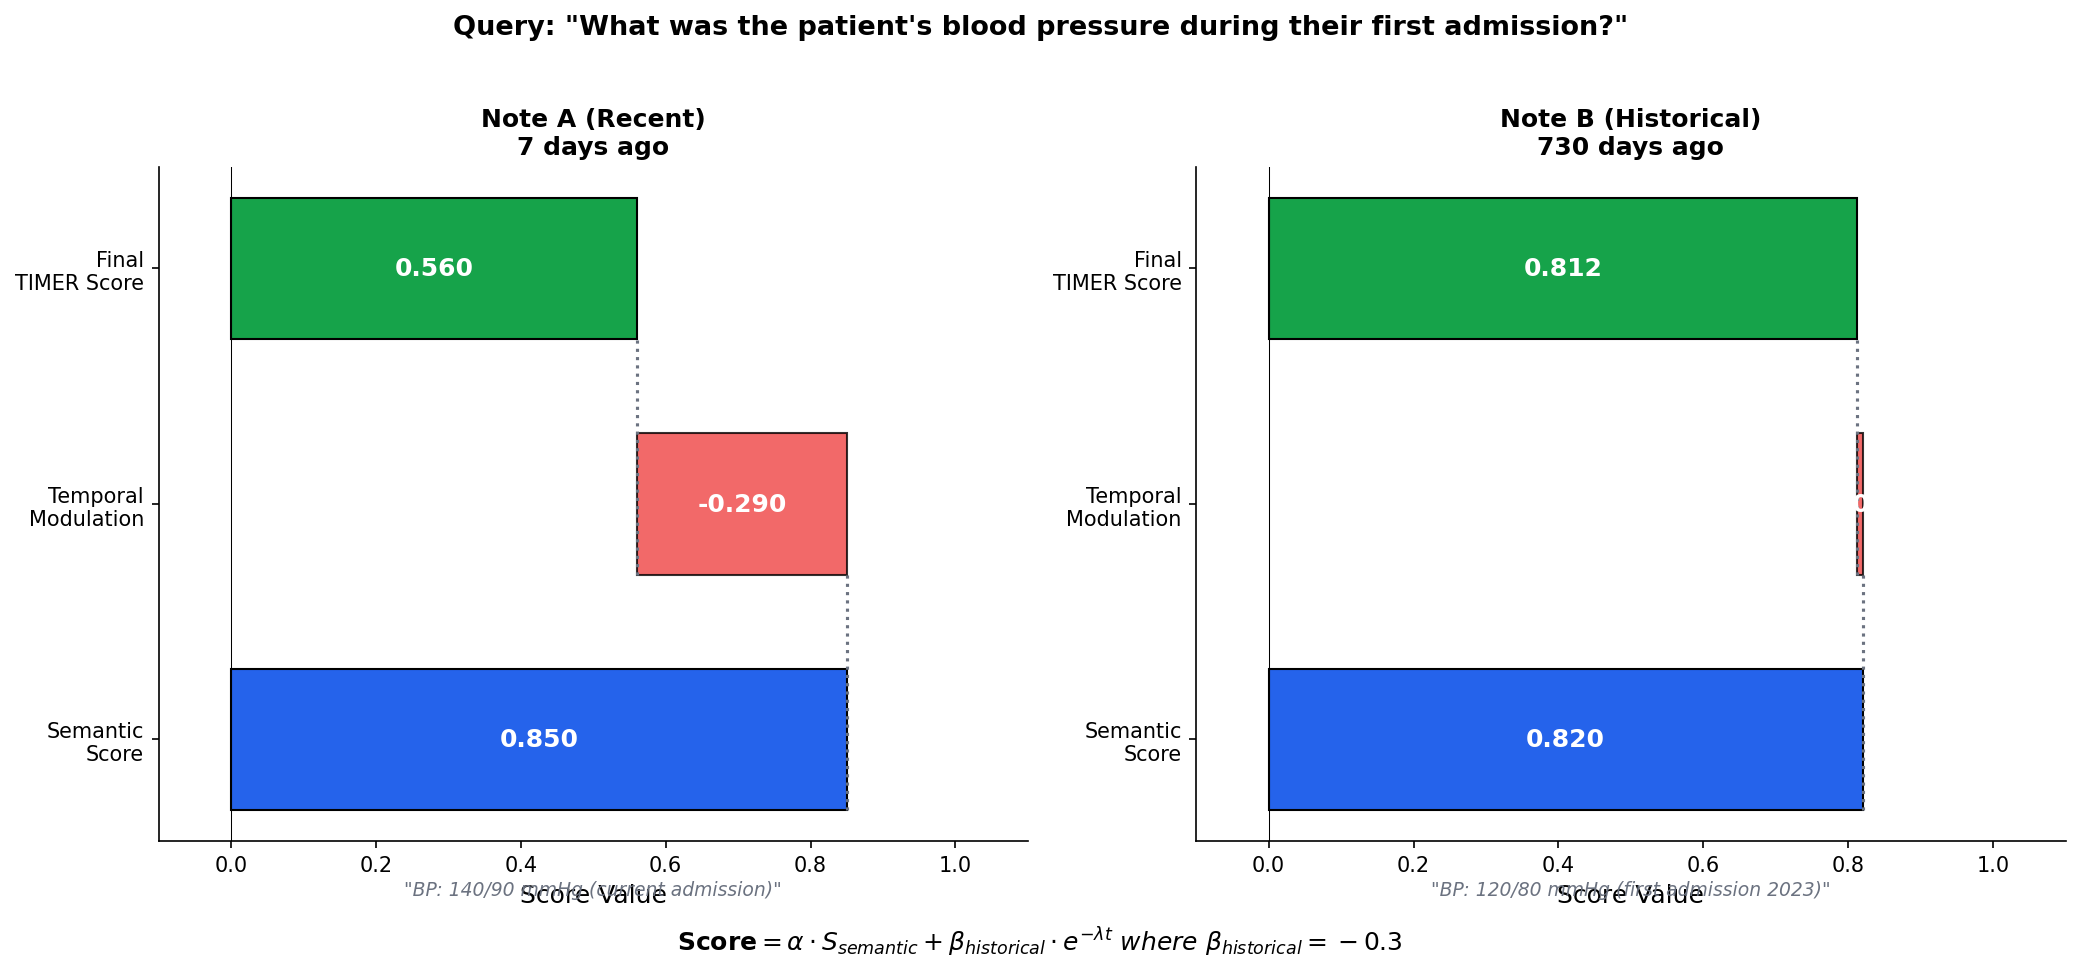

In [6]:
# === Figure 2: Score Component Waterfall ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, note in zip(axes, scenario['notes']):
    # Waterfall components
    components = ['Semantic\nScore', 'Temporal\nModulation', 'Final\nTIMER Score']
    values = [note['semantic'], note['temporal_contrib'], note['timer_score']]
    
    # Starting positions for waterfall
    starts = [0, note['semantic'], 0]
    widths = [note['semantic'], note['temporal_contrib'], note['timer_score']]
    
    # Colors
    colors = [COLORS['primary'], 
              COLORS['historical'] if note['temporal_contrib'] < 0 else COLORS['current'],
              COLORS['success']]
    
    # Create horizontal bars
    y_pos = np.arange(len(components))
    
    # Semantic bar
    ax.barh(y_pos[0], note['semantic'], color=COLORS['primary'], edgecolor='black', height=0.6)
    ax.text(note['semantic']/2, y_pos[0], f"{note['semantic']:.3f}", 
           ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    
    # Temporal bar (can be negative)
    temporal_color = COLORS['historical'] if note['temporal_contrib'] < 0 else COLORS['current']
    ax.barh(y_pos[1], note['temporal_contrib'], left=note['semantic'], 
           color=temporal_color, edgecolor='black', height=0.6, alpha=0.8)
    t_label_pos = note['semantic'] + note['temporal_contrib']/2
    ax.text(t_label_pos, y_pos[1], f"{note['temporal_contrib']:+.3f}", 
           ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    
    # Final score bar
    ax.barh(y_pos[2], note['timer_score'], color=COLORS['success'], edgecolor='black', height=0.6)
    ax.text(note['timer_score']/2, y_pos[2], f"{note['timer_score']:.3f}", 
           ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    
    # Connector lines
    ax.plot([note['semantic'], note['semantic']], [-0.3, 0.7], 
           color=COLORS['neutral'], linestyle=':', linewidth=1.5)
    ax.plot([note['timer_score'], note['timer_score']], [0.7, 1.7],
           color=COLORS['neutral'], linestyle=':', linewidth=1.5)
    
    # Styling
    ax.set_yticks(y_pos)
    ax.set_yticklabels(components)
    ax.set_xlim(-0.1, 1.1)
    ax.set_xlabel('Score Value')
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    # Title with note info
    ax.set_title(f"{note['id']}\n{note['offset_days']} days ago", fontsize=12, fontweight='bold')
    
    # Add clinical context
    ax.text(0.5, -0.6, f'"{note["content"]}"', ha='center', va='top', 
           fontsize=9, style='italic', color=COLORS['neutral'],
           transform=ax.get_yaxis_transform())

# Add formula annotation
fig.text(0.5, -0.02, r'$\mathbf{Score} = \alpha \cdot S_{semantic} + \beta_{historical} \cdot e^{-\lambda t}$ where $\beta_{historical} = -0.3$',
        ha='center', fontsize=12, style='italic')

plt.suptitle(f'Query: "{scenario["query"]}"', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ex2_score_waterfall.png', bbox_inches='tight', facecolor='white')
plt.savefig(PLOTS_DIR / 'ex2_score_waterfall.pdf', bbox_inches='tight')
print(f'✓ Saved: {PLOTS_DIR}/ex2_score_waterfall.png')
plt.show()

✓ Saved: plots/ex3_ranking_comparison.png


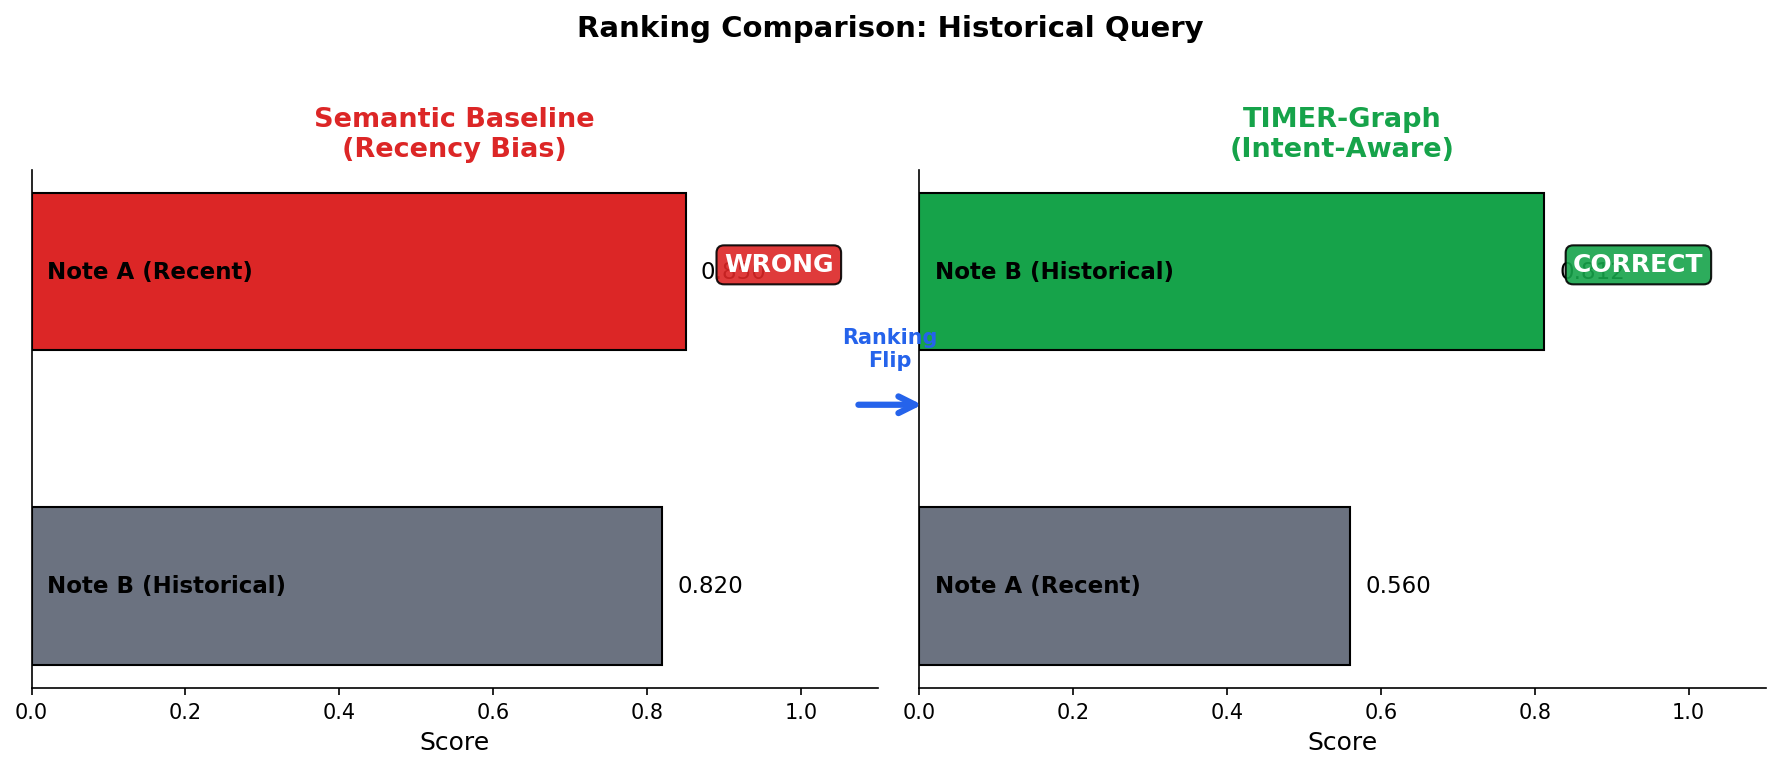

In [7]:
# === Figure 3: Ranking Comparison (Before/After TIMER) ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sort notes by different scores
notes_by_baseline = sorted(scenario['notes'], key=lambda x: x['baseline_score'], reverse=True)
notes_by_timer = sorted(scenario['notes'], key=lambda x: x['timer_score'], reverse=True)

# Left: Baseline ranking
ax = axes[0]
y_pos = [1, 0]
bar_colors = [COLORS['secondary'] if 'Recent' in n['id'] else COLORS['neutral'] for n in notes_by_baseline]

bars = ax.barh(y_pos, [n['baseline_score'] for n in notes_by_baseline], 
               color=bar_colors, edgecolor='black', height=0.5)

for i, (bar, note) in enumerate(zip(bars, notes_by_baseline)):
    ax.text(0.02, y_pos[i], note['id'], ha='left', va='center', fontsize=11, fontweight='bold')
    ax.text(bar.get_width() + 0.02, y_pos[i], f'{note["baseline_score"]:.3f}', 
           ha='left', va='center', fontsize=11)

ax.set_title('Semantic Baseline\n(Recency Bias)', fontsize=13, fontweight='bold', color=COLORS['secondary'])
ax.set_xlim(0, 1.1)
ax.set_yticks([])
ax.set_xlabel('Score')

# Winner indicator
ax.annotate('WRONG', xy=(0.9, 1), fontsize=12, fontweight='bold', color='white',
           bbox=dict(boxstyle='round', facecolor=COLORS['secondary'], alpha=0.9))

# Right: TIMER ranking
ax = axes[1]
bar_colors = [COLORS['success'] if 'Historical' in n['id'] else COLORS['neutral'] for n in notes_by_timer]

bars = ax.barh(y_pos, [n['timer_score'] for n in notes_by_timer], 
               color=bar_colors, edgecolor='black', height=0.5)

for i, (bar, note) in enumerate(zip(bars, notes_by_timer)):
    ax.text(0.02, y_pos[i], note['id'], ha='left', va='center', fontsize=11, fontweight='bold')
    ax.text(bar.get_width() + 0.02, y_pos[i], f'{note["timer_score"]:.3f}', 
           ha='left', va='center', fontsize=11)

ax.set_title('TIMER-Graph\n(Intent-Aware)', fontsize=13, fontweight='bold', color=COLORS['success'])
ax.set_xlim(0, 1.1)
ax.set_yticks([])
ax.set_xlabel('Score')

# Winner indicator
ax.annotate('CORRECT', xy=(0.85, 1), fontsize=12, fontweight='bold', color='white',
           bbox=dict(boxstyle='round', facecolor=COLORS['success'], alpha=0.9))

# Add ranking flip arrow
fig.patches.append(mpatches.FancyArrowPatch(
    (0.48, 0.5), (0.52, 0.5), 
    arrowstyle='->', mutation_scale=20,
    color=COLORS['primary'], linewidth=3,
    transform=fig.transFigure
))
fig.text(0.5, 0.55, 'Ranking\nFlip', ha='center', fontsize=10, fontweight='bold', color=COLORS['primary'])

plt.suptitle(f'Ranking Comparison: Historical Query', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ex3_ranking_comparison.png', bbox_inches='tight', facecolor='white')
plt.savefig(PLOTS_DIR / 'ex3_ranking_comparison.pdf', bbox_inches='tight')
print(f'✓ Saved: {PLOTS_DIR}/ex3_ranking_comparison.png')
plt.show()

---
## 4. Temporal Decay Surface Plot

3D visualization showing how scores vary with both time and beta.

✓ Saved: plots/ex4_score_heatmap.png


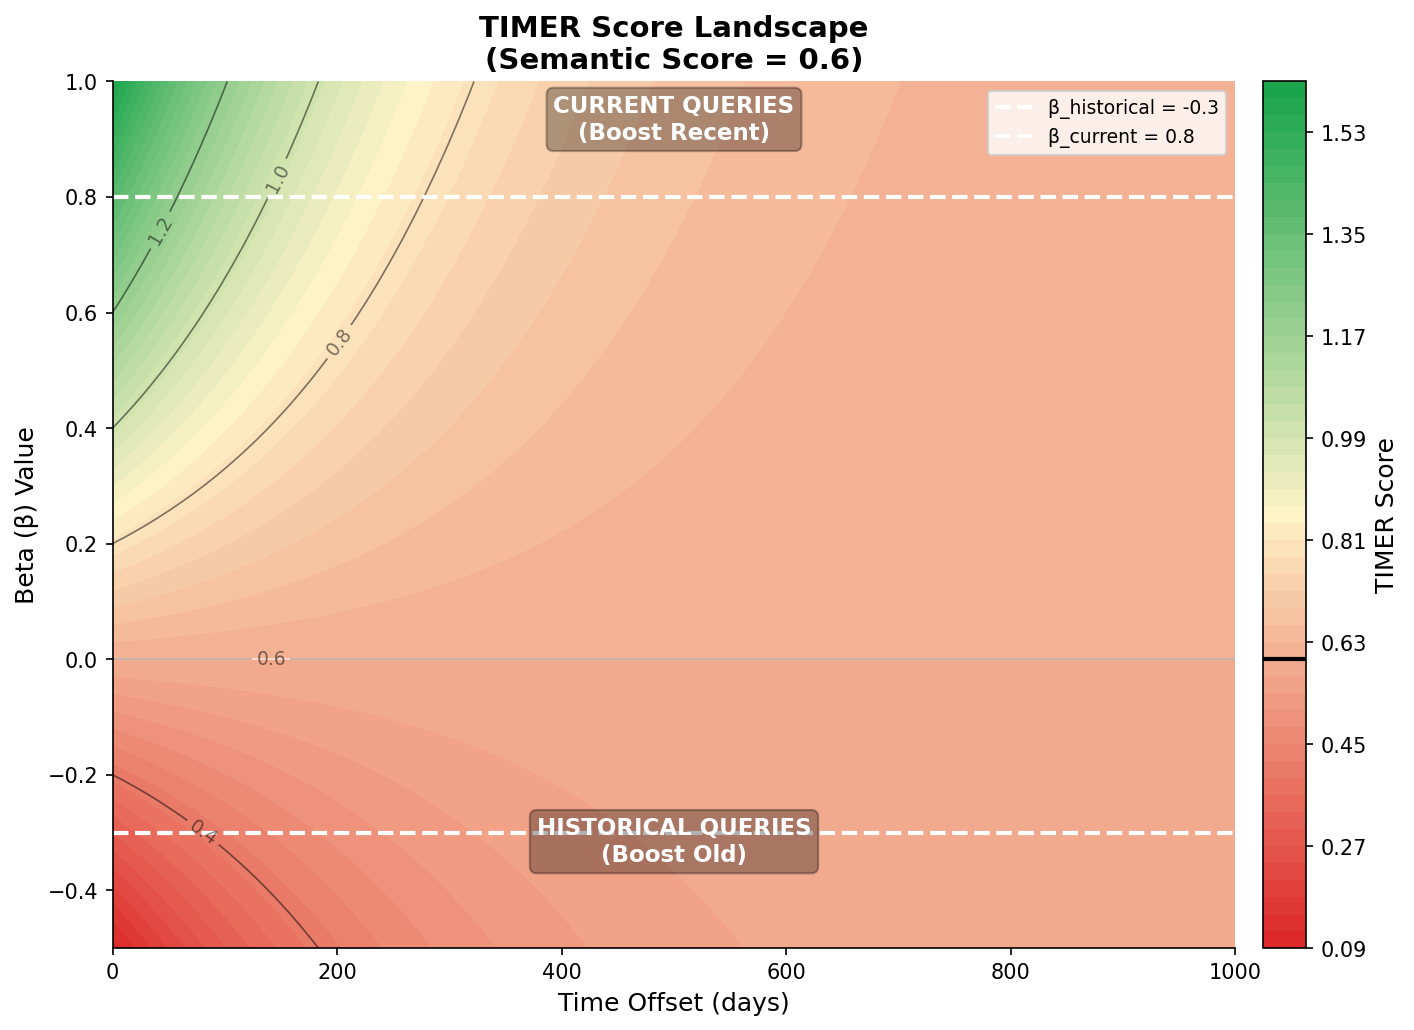

In [8]:
# === Figure 4: 2D Heatmap of Score vs Time and Beta ===
fig, ax = plt.subplots(figsize=(10, 7))

# Create grid
times = np.linspace(0, 1000, 100)
betas = np.linspace(-0.5, 1.0, 100)
T, B = np.meshgrid(times, betas)

# Fixed semantic score
semantic = 0.6

# Compute TIMER scores
decay = np.exp(-TIMERScorer.LAMBDA_DECAY * T)
scores = semantic + B * decay

# Create heatmap
cmap = LinearSegmentedColormap.from_list('timer', ['#DC2626', '#FEF3C7', '#16A34A'])
im = ax.contourf(T, B, scores, levels=50, cmap=cmap)

# Add contour lines
contours = ax.contour(T, B, scores, levels=[0.4, 0.6, 0.8, 1.0, 1.2], colors='black', alpha=0.5, linewidths=0.8)
ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f')

# Mark key beta values
ax.axhline(y=TIMERScorer.BETA_HISTORICAL, color='white', linestyle='--', linewidth=2, label=f'β_historical = {TIMERScorer.BETA_HISTORICAL}')
ax.axhline(y=0, color='white', linestyle='-', linewidth=1, alpha=0.5)
ax.axhline(y=TIMERScorer.BETA_CURRENT, color='white', linestyle='--', linewidth=2, label=f'β_current = {TIMERScorer.BETA_CURRENT}')

# Add annotations for regions
ax.text(500, 0.9, 'CURRENT QUERIES\n(Boost Recent)', ha='center', fontsize=11, 
       fontweight='bold', color='white', bbox=dict(facecolor='black', alpha=0.3, boxstyle='round'))
ax.text(500, -0.35, 'HISTORICAL QUERIES\n(Boost Old)', ha='center', fontsize=11,
       fontweight='bold', color='white', bbox=dict(facecolor='black', alpha=0.3, boxstyle='round'))

# Colorbar
cbar = plt.colorbar(im, ax=ax, label='TIMER Score', pad=0.02)
cbar.ax.axhline(y=semantic, color='black', linewidth=2, label='Semantic Only')

ax.set_xlabel('Time Offset (days)', fontsize=12)
ax.set_ylabel('Beta (β) Value', fontsize=12)
ax.set_title('TIMER Score Landscape\n(Semantic Score = 0.6)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ex4_score_heatmap.png', bbox_inches='tight', facecolor='white')
plt.savefig(PLOTS_DIR / 'ex4_score_heatmap.pdf', bbox_inches='tight')
print(f'✓ Saved: {PLOTS_DIR}/ex4_score_heatmap.png')
plt.show()

---
## 5. Pattern Matching Visualization

Highlighting which words in a query triggered intent classification.

✓ Saved: plots/ex5_pattern_highlighting.png


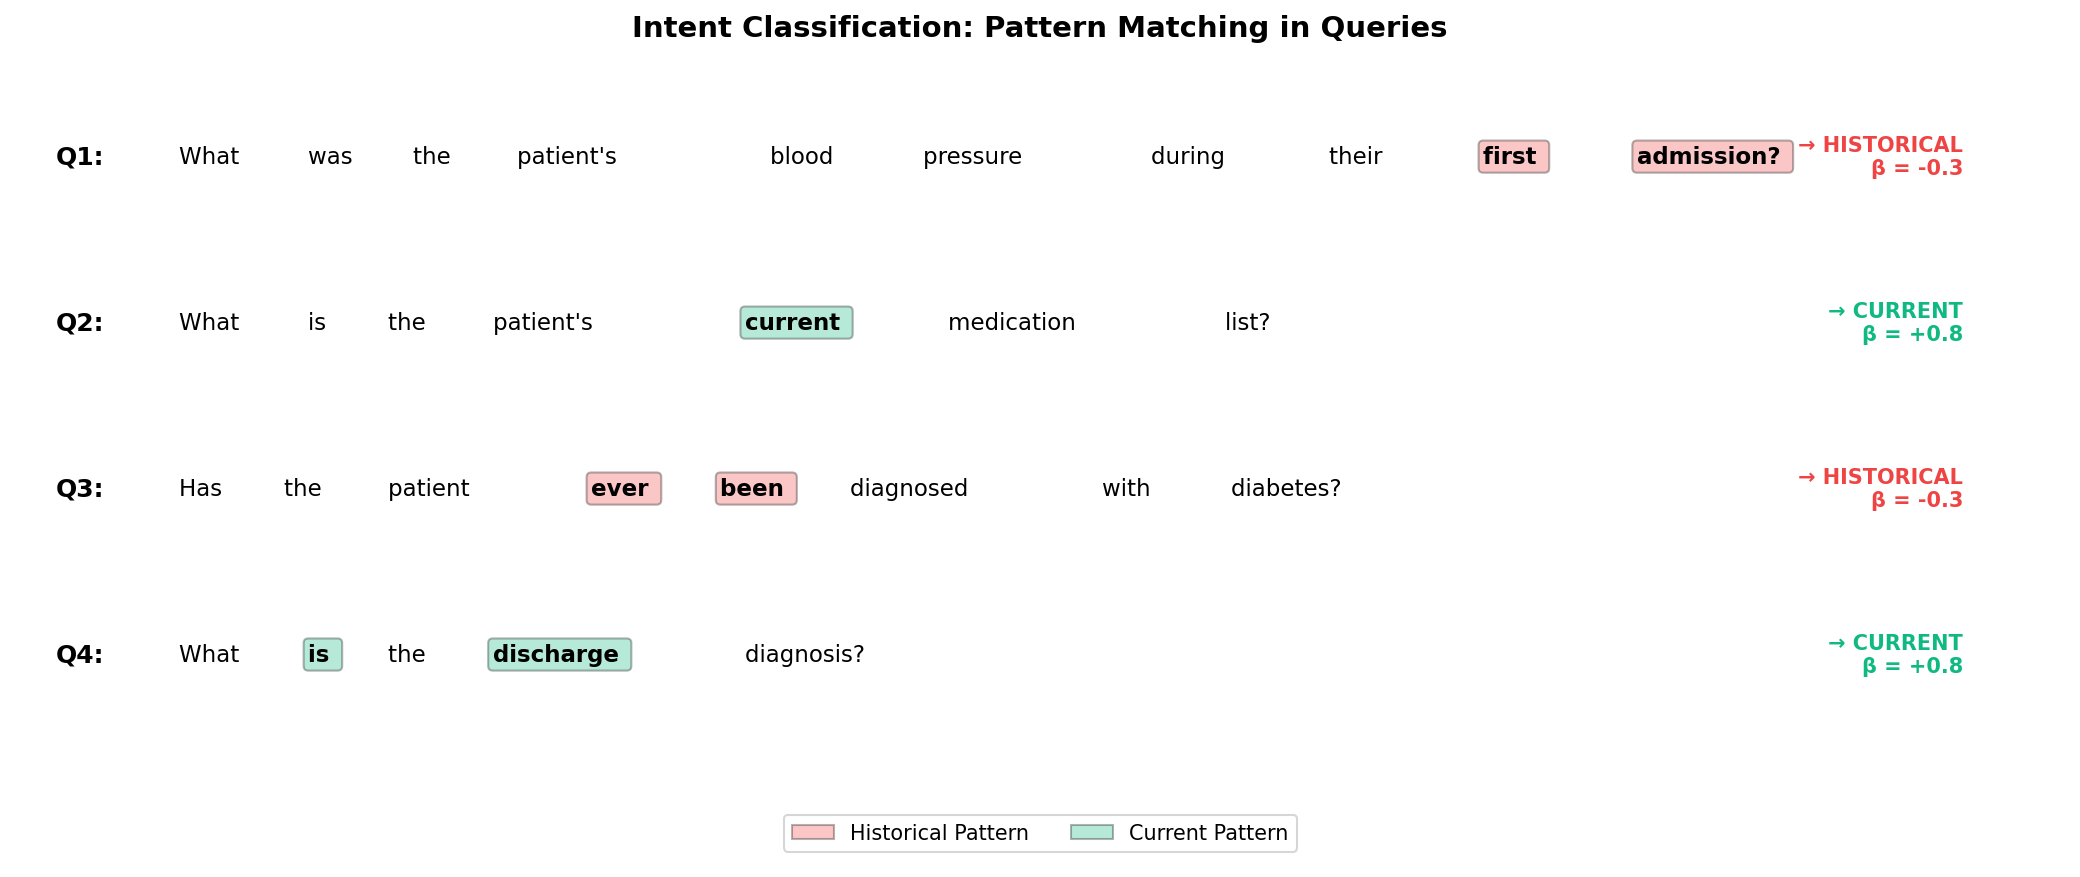

In [9]:
# === Figure 5: Query Token Highlighting ===
def highlight_patterns(query, historical_patterns, current_patterns):
    """Create highlighted version of query showing pattern matches."""
    query_lower = query.lower()
    words = query.split()
    highlights = []
    
    for word in words:
        word_lower = word.lower().strip('?.,!')
        h_match = any(re.search(p, word_lower) for p in historical_patterns)
        c_match = any(re.search(p, word_lower) for p in current_patterns)
        
        # Also check multi-word patterns
        for p in historical_patterns:
            if re.search(p, query_lower):
                match = re.search(p, query_lower)
                if match and word_lower in match.group():
                    h_match = True
        for p in current_patterns:
            if re.search(p, query_lower):
                match = re.search(p, query_lower)
                if match and word_lower in match.group():
                    c_match = True
        
        if h_match:
            highlights.append(('historical', word))
        elif c_match:
            highlights.append(('current', word))
        else:
            highlights.append(('neutral', word))
    
    return highlights

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

y_positions = [0.85, 0.65, 0.45, 0.25]

for idx, qa in enumerate(query_analysis):
    y = y_positions[idx]
    highlights = highlight_patterns(qa['text'], TIMERScorer.HISTORICAL_PATTERNS, TIMERScorer.CURRENT_PATTERNS)
    
    # Draw query ID
    ax.text(0.02, y, f"{qa['id']}:", fontsize=12, fontweight='bold', va='center')
    
    # Draw each word with highlighting
    x_offset = 0.08
    for token_type, word in highlights:
        if token_type == 'historical':
            color = COLORS['historical']
            bg_alpha = 0.3
        elif token_type == 'current':
            color = COLORS['current']
            bg_alpha = 0.3
        else:
            color = 'black'
            bg_alpha = 0
        
        if bg_alpha > 0:
            ax.text(x_offset, y, word + ' ', fontsize=11, va='center', 
                   bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=bg_alpha),
                   fontweight='bold')
        else:
            ax.text(x_offset, y, word + ' ', fontsize=11, va='center', color=color)
        
        x_offset += len(word) * 0.012 + 0.015
    
    # Add result annotation
    intent = qa['detected_intent']
    result_color = COLORS['historical'] if intent == 'historical' else COLORS['current']
    ax.text(0.95, y, f"→ {intent.upper()}\nβ = {qa['beta']:+.1f}", 
           fontsize=10, fontweight='bold', color=result_color, ha='right', va='center')

# Legend
legend_elements = [
    mpatches.Patch(facecolor=COLORS['historical'], alpha=0.3, edgecolor='black', label='Historical Pattern'),
    mpatches.Patch(facecolor=COLORS['current'], alpha=0.3, edgecolor='black', label='Current Pattern'),
]
ax.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10)

ax.set_title('Intent Classification: Pattern Matching in Queries', fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ex5_pattern_highlighting.png', bbox_inches='tight', facecolor='white')
plt.savefig(PLOTS_DIR / 'ex5_pattern_highlighting.pdf', bbox_inches='tight')
print(f'✓ Saved: {PLOTS_DIR}/ex5_pattern_highlighting.png')
plt.show()

---
## Summary

This notebook generated **5 detailed example visualizations**:

1. **ex1_intent_classification.png** - Pattern matching bar charts for 4 queries
2. **ex2_score_waterfall.png** - Component breakdown (semantic + temporal)
3. **ex3_ranking_comparison.png** - Before/after ranking flip
4. **ex4_score_heatmap.png** - Score landscape across time and beta
5. **ex5_pattern_highlighting.png** - Word-level pattern highlighting

In [10]:
# List generated files
print('\n=== Generated Example Visualizations ===')
for f in sorted(PLOTS_DIR.glob('ex*.png')):
    print(f'  ✓ {f.name}')


=== Generated Example Visualizations ===
  ✓ ex1_intent_classification.png
  ✓ ex2_score_waterfall.png
  ✓ ex3_ranking_comparison.png
  ✓ ex4_score_heatmap.png
  ✓ ex5_pattern_highlighting.png
